# Tutorial for using the ModuleProperties, CombiningModules and RunSSA classes

In [1]:
from THE_OOP import *
import numpy as np

/Users/willalston/Desktop/Msci_Project/git_repos/students/Will/Code_for_submission/THE_OOP.py:46: SyntaxWarning: invalid escape sequence '\m'
  chem_pot = symbols(f"\mu_{species_symbol}")


# Define reaction networks 

### NOTE: These two are the examples from the Raux 2025 paper. 'species_names' must be in the same order as the rows of the stoich matrix

In [2]:

# Network 1

SM1 = Matrix( [[-1,1,0], [1,-1,-1], [0,0,1], [-1,0,-1], [0,1,0]])

species_names1 = ["A1", "A2","A3","S","Na"]

num_internal_species1 = 3


# Network 2

SM2 = Matrix([[-1, 0, 1, 0, 0], # first row of internal
                           [1, -1, 0, -1, 0], 
                           [0, 1, -1, 0, 1], 
                           [0, 0, 0, 1, -1],
                             [0, 0, 0, -1, 0], # first row external 
                             [0, 0, 0, 0, 1],
                             [-1, 0, 0, 0, 0],
                             [0, 0, 1, 0, 0]])


species_names2 = ["B1", "B2", "B3", "B4", "Na", "Nb", "F", "W"]

num_internal_species2 = 4


# ModuleProperties

## Creating the ModuleProperties object for a network and extracting useful algebraic constructs:

In [3]:
# Create the object

CRN_1 = ModuleProperties(SM1, num_internal_species1, species_names1)

In [4]:
# Internal and External Stoichiometric Matrices

print("Internal SM: ")
display(CRN_1.internal_stoich_matrix)

print(" ")
print("External SM: ")
display(CRN_1.external_stoich_matrix)

Internal SM: 


⎡-1  1   0 ⎤
⎢          ⎥
⎢1   -1  -1⎥
⎢          ⎥
⎣0   0   1 ⎦

 
External SM: 


⎡-1  0  -1⎤
⎢         ⎥
⎣0   1  0 ⎦

In [5]:
# Cycle Matrix and Coupling Matrix

print("Cycle Matrix: ")
display(CRN_1.cycle_matrix)

print(" ") 
print("Coupling Matrix: ")
display(CRN_1.coupling_matrix) 

Cycle Matrix: 


⎡1⎤
⎢ ⎥
⎢1⎥
⎢ ⎥
⎣0⎦

 
Coupling Matrix: 


⎡-1⎤
⎢  ⎥
⎣1 ⎦

In [6]:
# The Conservation Law matrix and the Chemostat Conservation Laws

print("Full Conservation Law matrix: ")
display(CRN_1.cons_laws)

print(" ")
print("Chemostat Conservation Laws: ")
display(CRN_1.chemostat_cons_laws)

Full Conservation Law matrix: 


⎡1   1   1  0  0⎤
⎢               ⎥
⎣-2  -1  0  1  1⎦

 
Chemostat Conservation Laws: 


[1  1]

In [7]:
# Selection Matrix and Physical Currents

# Note: Since we are dealing with current equivalences, labelling may differ from an analytical solution, but is mathematically correct.

print("Selection Matrix: ")
display(CRN_1.selection_matrix)

print(" ")
print("Physical Currents: ")
display(CRN_1.physical_currents)

Selection Matrix: 


⎡-1⎤
⎢  ⎥
⎣1 ⎦

 
Physical Currents: 


⎡j₂ ⎤
⎢   ⎥
⎣-j₂⎦

## Finding the Resistance/Conductance Matrix

### Note: Invert for the corresponding conductance matrices via Matrix.inv(). This may take a while for large matrices.


In [8]:
# Kinetic level: 

CRN_1.calculate_reaction_resistance_matrix()

⎡r₁  0   0 ⎤
⎢          ⎥
⎢0   r₂  0 ⎥
⎢          ⎥
⎣0   0   r₃⎦

In [9]:
# Cycle level:

CRN_1.calculate_cycle_resistance_matrix()

[r₁ + r₂]

In [10]:
# Physical level: (Conductance Matrix)

CRN_1.calculate_physical_conductance_matrix()

⎡   1       -1   ⎤
⎢───────  ───────⎥
⎢r₁ + r₂  r₁ + r₂⎥
⎢                ⎥
⎢  -1        1   ⎥
⎢───────  ───────⎥
⎣r₁ + r₂  r₁ + r₂⎦

In [11]:
# Fundamental level: 

CRN_1.calculate_fundamental_resistance_matrix()

[r₁ + r₂]

# Symbolic Combination

### Demonstration 1: Serial Connection of two networks

##### For the first demonstration we will use the networks defined previously, following the example in Raux 2025. 

In [12]:
Module1 = CRN_1
Module2 = ModuleProperties(SM2, num_internal_species2, species_names2)

# Must Create the fundamental Resistance Matrices before Combining (code quirk, could be changed).

Module1.calculate_fundamental_resistance_matrix()
Module2.calculate_fundamental_resistance_matrix()

⎡r₂ + r₄ + r₅      -r₂     ⎤
⎢                          ⎥
⎣    -r₂       r₁ + r₂ + r₃⎦

In [13]:
# Create the combined module object

New_Module = CombiningModules(Module1, Module2)

Direct derivation force ordering:
  row/col 0: F-W        → resistance r4+r5+r6
  row/col 1: ???        → resistance r10+r9
  row/col 2: S-Pb       → resistance r1+r11+r12+r2+r5+r7+r8
  row/col 3: Ne-Pe      → resistance r13+r14

r9  = resistance of reaction 9  in M3 (shifted from r1 in M3 unshifted)
r10 = resistance of reaction 10 in M3 (shifted from r2 in M3 unshifted)
r11 = resistance of reaction 11 in M3
r12 = resistance of reaction 12 in M3
r13 = resistance of reaction 13 in M3
r14 = resistance of reaction 14 in M3

M3 has reactions c1..c6, shifted by n_rxn_l=3
So M3 reaction c1 → r4, c2 → r5, etc.
r9=c1, r10=c2, r11=c3, r12=c4, r13=c5, r14=c6

c1,c2 form cycle ε_c  (Nex→Pex): resistance r9+r10
c3,c4 form cycle ε_c' (Nb→Pb):   resistance r11+r12
c5,c6 form cycle ε_c''(Ne→Pe):   resistance r13+r14

STEP 1: IDENTIFY INTERFACE SPECIES
left_ext_names_list:  ['S', 'Na']
right_ext_names_list: ['Na', 'Nb', 'F', 'W']
interface_names:      ['Na']
left_free_rows:       [0]
right_free_rows: 

In [14]:
# And calculate the fundamental resistance matrix. (Invert for Conductance Matrix)

New_Module.fundamental_resistance_matrix

⎡r₁ + r₂ + r₅ + r₇ + r₈      -r₅     ⎤
⎢                                    ⎥
⎣         -r₅            r₄ + r₅ + r₆⎦

##### Verifying Solution using the code:

In [15]:
# It can be labourious to find by hand the joint network with which to find the overall network. We can use CombiningModules
# attributes to create a new MP object, and compare the resistance matrix from this to our answer. This new object can be used in
# exactly the same fashion as before.

Joint_Network = ModuleProperties(New_Module.stoich_matrix, New_Module.num_internal_species, New_Module.species_names)

Joint_Network.calculate_fundamental_resistance_matrix()

⎡r₁ + r₂ + r₅ + r₇ + r₈      -r₅     ⎤
⎢                                    ⎥
⎣         -r₅            r₄ + r₅ + r₆⎦

### Demonstration 2: Serial Combination of more than two networks

In [16]:
# Create two new modules. These are adapted from the Avanzini Paper

# Network 3

SM3=Matrix([
    [-1,1,-1,1,0,0],
    [1,-1,0,0,0,0],
    [0,0,1,-1,0,0],
    [0,0,0,0,-1,1],
    [0,0,0,0,1,-1],
    [-1,0,0,0,0,0],
    [0,0,-1,0,0,0],
    [0,0,0,0,-1,0],
    [0,1,0,0,0,0],
    [0,0,0,1,0,0],
    [0,0,0,0,0,1]
])

species_names3 = ["C1", "C2", "C3", "C4", "C5", "Nex","Nb","Ne","Pex","Pb","Pe"]


# Network 4

SM4 = Matrix([[-1,0,1,0,-1],
            [0,-1,0,1,1],
            [1,1,-1,-1,0],
            [-1,-1,0,0,0],
            [0,0,1,1,0]])


species_names4 = ["D1", "D2", "D3", "Nd", "S"] 

# Again, create MP objects and calculate the resistance matrices

Module3 = ModuleProperties(SM3, 5, species_names3)
display(Module3.calculate_fundamental_resistance_matrix())

Module4 = ModuleProperties(SM4, 3, species_names4)
display(Module4.calculate_fundamental_resistance_matrix())

⎡r₁ + r₂     0        0   ⎤
⎢                         ⎥
⎢   0     r₃ + r₄     0   ⎥
⎢                         ⎥
⎣   0        0     r₅ + r₆⎦

⎡r₁⋅r₂⋅r₃ + r₁⋅r₂⋅r₄ + r₁⋅r₂⋅r₅ + r₁⋅r₃⋅r₄ + r₁⋅r₄⋅r₅ + r₂⋅r₃⋅r₄ + r₂⋅r₃⋅r₅ +  ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎣            r₁⋅r₃ + r₁⋅r₄ + r₁⋅r₅ + r₂⋅r₃ + r₂⋅r₄ + r₂⋅r₅ + r₃⋅r₅ + r₄⋅r₅     ↪

↪ r₃⋅r₄⋅r₅⎤
↪ ────────⎥
↪         ⎦

In [17]:
# We can use the code to construct a larger serial network in any order, here we choose to connect M4 to M1, then add on the other 
# modules.

# STEP 1: Combine Module 4 to Module 1:

joint_CRN_1 = CombiningModules(Module4, Module1)

display(joint_CRN_1.fundamental_resistance_matrix)


Direct derivation force ordering:
  row/col 0: F-W        → resistance r4+r5+r6
  row/col 1: ???        → resistance r10+r9
  row/col 2: S-Pb       → resistance r1+r11+r12+r2+r5+r7+r8
  row/col 3: Ne-Pe      → resistance r13+r14

r9  = resistance of reaction 9  in M3 (shifted from r1 in M3 unshifted)
r10 = resistance of reaction 10 in M3 (shifted from r2 in M3 unshifted)
r11 = resistance of reaction 11 in M3
r12 = resistance of reaction 12 in M3
r13 = resistance of reaction 13 in M3
r14 = resistance of reaction 14 in M3

M3 has reactions c1..c6, shifted by n_rxn_l=5
So M3 reaction c1 → r6, c2 → r7, etc.
r9=c1, r10=c2, r11=c3, r12=c4, r13=c5, r14=c6

c1,c2 form cycle ε_c  (Nex→Pex): resistance r9+r10
c3,c4 form cycle ε_c' (Nb→Pb):   resistance r11+r12
c5,c6 form cycle ε_c''(Ne→Pe):   resistance r13+r14

STEP 1: IDENTIFY INTERFACE SPECIES
left_ext_names_list:  ['Nd', 'S']
right_ext_names_list: ['S', 'Na']
interface_names:      ['S']
left_free_rows:       [0]
right_free_rows:      [1]

ST

⎡          r₁⋅r₂⋅r₃ + r₁⋅r₂⋅r₄ + r₁⋅r₂⋅r₅ + r₁⋅r₃⋅r₄ + r₁⋅r₄⋅r₅ + r₂⋅r₃⋅r₄ + r ↪
⎢r₆ + r₇ + ─────────────────────────────────────────────────────────────────── ↪
⎣                      r₁⋅r₃ + r₁⋅r₄ + r₁⋅r₅ + r₂⋅r₃ + r₂⋅r₄ + r₂⋅r₅ + r₃⋅r₅ + ↪

↪ ₂⋅r₃⋅r₅ + r₃⋅r₄⋅r₅⎤
↪ ──────────────────⎥
↪  r₄⋅r₅            ⎦

In [18]:
# STEP 2: Add on Module 2 to this new combined network (directly using the newly constructed CombiningModules object)

joint_CRN_2 = CombiningModules(joint_CRN_1, Module2)

display(joint_CRN_2.fundamental_resistance_matrix)


Direct derivation force ordering:
  row/col 0: F-W        → resistance r4+r5+r6
  row/col 1: ???        → resistance r10+r9
  row/col 2: S-Pb       → resistance r1+r11+r12+r2+r5+r7+r8
  row/col 3: Ne-Pe      → resistance r13+r14

r9  = resistance of reaction 9  in M3 (shifted from r1 in M3 unshifted)
r10 = resistance of reaction 10 in M3 (shifted from r2 in M3 unshifted)
r11 = resistance of reaction 11 in M3
r12 = resistance of reaction 12 in M3
r13 = resistance of reaction 13 in M3
r14 = resistance of reaction 14 in M3

M3 has reactions c1..c6, shifted by n_rxn_l=8
So M3 reaction c1 → r9, c2 → r10, etc.
r9=c1, r10=c2, r11=c3, r12=c4, r13=c5, r14=c6

c1,c2 form cycle ε_c  (Nex→Pex): resistance r9+r10
c3,c4 form cycle ε_c' (Nb→Pb):   resistance r11+r12
c5,c6 form cycle ε_c''(Ne→Pe):   resistance r13+r14

STEP 1: IDENTIFY INTERFACE SPECIES
left_ext_names_list:  ['Nd', 'Na']
right_ext_names_list: ['Na', 'Nb', 'F', 'W']
interface_names:      ['Na']
left_free_rows:       [0]
right_free_rows

⎡                            r₁⋅r₂⋅r₃ + r₁⋅r₂⋅r₄ + r₁⋅r₂⋅r₅ + r₁⋅r₃⋅r₄ + r₁⋅r₄ ↪
⎢r₁₀ + r₁₂ + r₁₃ + r₆ + r₇ + ───────────────────────────────────────────────── ↪
⎢                                        r₁⋅r₃ + r₁⋅r₄ + r₁⋅r₅ + r₂⋅r₃ + r₂⋅r₄ ↪
⎢                                                                              ↪
⎣                                                      -r₁₀                    ↪

↪ ⋅r₅ + r₂⋅r₃⋅r₄ + r₂⋅r₃⋅r₅ + r₃⋅r₄⋅r₅                ⎤
↪ ────────────────────────────────────       -r₁₀     ⎥
↪  + r₂⋅r₅ + r₃⋅r₅ + r₄⋅r₅                            ⎥
↪                                                     ⎥
↪                                       r₁₀ + r₁₁ + r₉⎦

In [19]:
# STEP 3: Finally add the last module

joint_CRN_3 = CombiningModules(joint_CRN_2, Module3)

final_RM = joint_CRN_3.fundamental_resistance_matrix

Direct derivation force ordering:
  row/col 0: F-W        → resistance r4+r5+r6
  row/col 1: ???        → resistance r10+r9
  row/col 2: S-Pb       → resistance r1+r11+r12+r2+r5+r7+r8
  row/col 3: Ne-Pe      → resistance r13+r14

r9  = resistance of reaction 9  in M3 (shifted from r1 in M3 unshifted)
r10 = resistance of reaction 10 in M3 (shifted from r2 in M3 unshifted)
r11 = resistance of reaction 11 in M3
r12 = resistance of reaction 12 in M3
r13 = resistance of reaction 13 in M3
r14 = resistance of reaction 14 in M3

M3 has reactions c1..c6, shifted by n_rxn_l=13
So M3 reaction c1 → r14, c2 → r15, etc.
r9=c1, r10=c2, r11=c3, r12=c4, r13=c5, r14=c6

c1,c2 form cycle ε_c  (Nex→Pex): resistance r9+r10
c3,c4 form cycle ε_c' (Nb→Pb):   resistance r11+r12
c5,c6 form cycle ε_c''(Ne→Pe):   resistance r13+r14

STEP 1: IDENTIFY INTERFACE SPECIES
left_ext_names_list:  ['Nd', 'Nb', 'F', 'W']
right_ext_names_list: ['Nex', 'Nb', 'Ne', 'Pex', 'Pb', 'Pe']
interface_names:      ['Nb']
left_free_row

In [20]:
# The full networks Resistance Matrix is: 

final_RM

⎡r₁₀ + r₁₁ + r₉      0                                                         ↪
⎢                                                                              ↪
⎢      0         r₁₄ + r₁₅                                                     ↪
⎢                                                                              ↪
⎢                                                                   r₁⋅r₂⋅r₃ + ↪
⎢     -r₁₀           0      r₁₀ + r₁₂ + r₁₃ + r₁₆ + r₁₇ + r₆ + r₇ + ────────── ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎣      0             0                                                         ↪

↪           -r₁₀                                                               ↪
↪                                                                              ↪
↪             0                                                                ↪
↪                          

##### Verifying Result:

In [21]:
# This can take a long time. With four modules the symbolic computation becomes very large, so this is a suggested exercise to 
# convince the user that the code works for a more complicated example.

Overall_Module = ModuleProperties(joint_CRN_3.stoich_matrix, joint_CRN_3.num_internal_species, joint_CRN_3.species_names)

Overall_Module.calculate_fundamental_resistance_matrix()

⎡r₁₀ + r₁₁ + r₉      0                                                         ↪
⎢                                                                              ↪
⎢      0         r₁₄ + r₁₅                                                     ↪
⎢                                                                              ↪
⎢                           r₁⋅r₁₀⋅r₃ + r₁⋅r₁₀⋅r₄ + r₁⋅r₁₀⋅r₅ + r₁⋅r₁₂⋅r₃ + r₁ ↪
⎢     -r₁₀           0      ────────────────────────────────────────────────── ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎣      0             0                                                         ↪

↪                                                                              ↪
↪                                                                              ↪
↪                                                                              ↪
↪                          

# Numerical Conductance Matrix Simulation and Combination

### We can use RunSSA to run Gillespie SSA simulations for our seperate networks to find numerical conductance matrices.

These examples are for two networks. The same process can be applied iteratively to any number of networks required (has been tested up to four sets of numerical conductance matrices being connected).

##### Preparation

In [22]:
#
# Define initial populations of each species and reaction constants
#

# Module 1: [A1, A2, A3, S, Na]
initial_counts = [150, 50, 30, 152, 110]
rates = np.array([0.0005, 0.006, 0.010, 0.001, 0.0005, 0.008])

# Module 2: [B1, B2, B3, B4, Na, Nb, F, W]
initial_counts2 = [50, 50, 50, 80, 110, 100, 200, 80]
rates2 = np.array([0.0002, 0.010, 0.004, 0.004, 0.015, 0.0005, 0.0002, 0.012, 0.015, 0.0005])

# Module 3: [C1, C2, C3, C4, C5, Nex, Nb, Ne, Pex, Pb, Pe]
initial_counts3 = [100, 100, 200, 120, 50, 150, 100, 150, 80, 100, 80]
rates3 = np.array([0.0008, 0.003, 0.004, 0.002, 0.0002, 0.012, 0.015, 0.0005, 0.0005, 0.008, 0.010, 0.001])

# Module 4: [D1, D2, D3, Nd, S]
initial_counts4 = [150, 150, 50, 200, 152]
rates4 = np.array([0.0005, 0.006, 0.0005, 0.006, 0.010, 0.001, 0.008, 0.001, 0.003, 0.004])


simulation_length = 500.0
burn_in = 150.0

#
# Create RunSSA objects
# 

SIM1 = RunSSA(Module1, initial_counts, rates, simulation_length, burn_in)
SIM2 = RunSSA(Module2, initial_counts2, rates2, simulation_length, burn_in)
SIM3 = RunSSA(Module3, initial_counts3, rates3, simulation_length, burn_in)
SIM4 = RunSSA(Module4, initial_counts4, rates4, simulation_length, burn_in)

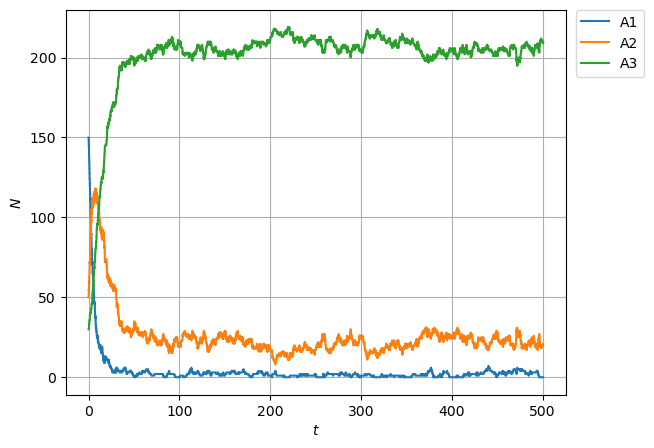

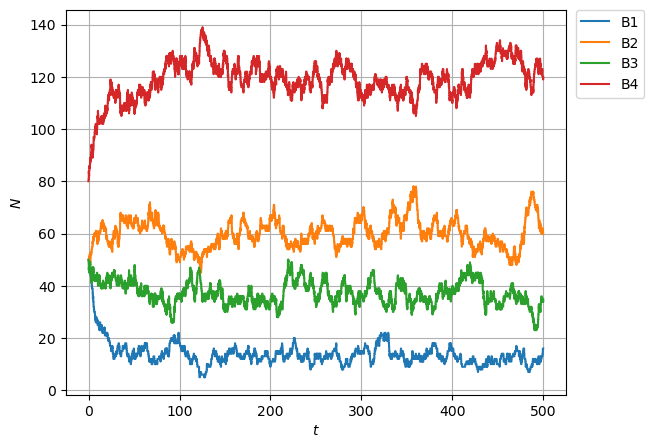

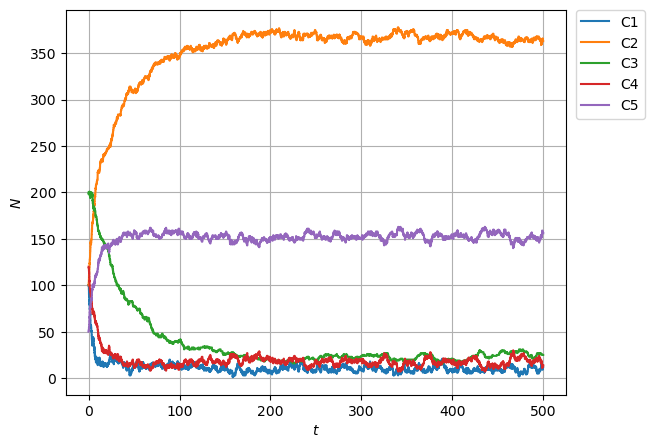

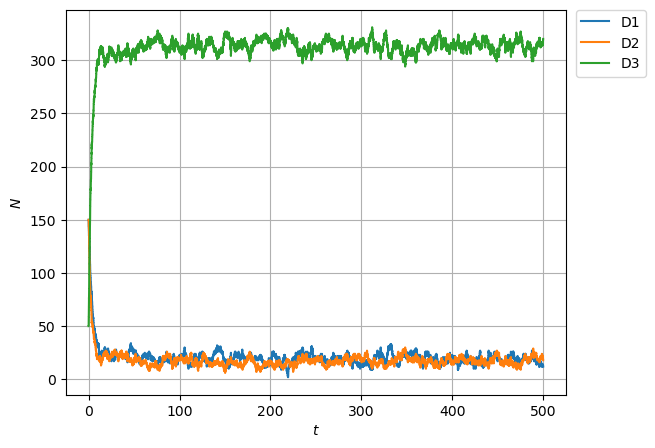

In [23]:
# To plot populations vs time:

SIM1.run_SSA_and_plot_counts(True)
SIM2.run_SSA_and_plot_counts(True)
SIM3.run_SSA_and_plot_counts(True)
SIM4.run_SSA_and_plot_counts(True)

### Demonstration 1: A Module with scalar fundamental conductance

In [24]:
# To simulate over a range of boundary conditions, use the run_IF_sweep method

# This line will: Run 100 SSA iterations and average per 50 different sets of A2,S defined in count_values. 
# The covariance_reaction_indices is
# the index of the symbolic current that contributes to the modules fundamental current (for Module 1 it is j1 => index = 0).

SIM1.run_IF_sweep(species_index=[1,3], 
                count_values=[np.linspace(100,200,50), np.linspace(50,75,50)],
                total_iterations=100,
                covariance_reaction_indices=[0],
                verbose=True)

Sweep 1/50  ([A2] = 100, [S] = 50)
Sweep 2/50  ([A2] = 102, [S] = 51)
Sweep 3/50  ([A2] = 104, [S] = 51)
Sweep 4/50  ([A2] = 106, [S] = 52)
Sweep 5/50  ([A2] = 108, [S] = 52)
Sweep 6/50  ([A2] = 110, [S] = 53)
Sweep 7/50  ([A2] = 112, [S] = 53)
Sweep 8/50  ([A2] = 114, [S] = 54)
Sweep 9/50  ([A2] = 116, [S] = 54)
Sweep 10/50  ([A2] = 118, [S] = 55)
Sweep 11/50  ([A2] = 120, [S] = 55)
Sweep 12/50  ([A2] = 122, [S] = 56)
Sweep 13/50  ([A2] = 124, [S] = 56)
Sweep 14/50  ([A2] = 127, [S] = 57)
Sweep 15/50  ([A2] = 129, [S] = 57)
Sweep 16/50  ([A2] = 131, [S] = 58)
Sweep 17/50  ([A2] = 133, [S] = 58)
Sweep 18/50  ([A2] = 135, [S] = 59)
Sweep 19/50  ([A2] = 137, [S] = 59)
Sweep 20/50  ([A2] = 139, [S] = 60)
Sweep 21/50  ([A2] = 141, [S] = 60)
Sweep 22/50  ([A2] = 143, [S] = 61)
Sweep 23/50  ([A2] = 145, [S] = 61)
Sweep 24/50  ([A2] = 147, [S] = 62)
Sweep 25/50  ([A2] = 149, [S] = 62)
Sweep 26/50  ([A2] = 151, [S] = 63)
Sweep 27/50  ([A2] = 153, [S] = 63)
Sweep 28/50  ([A2] = 155, [S] = 64)
S

(array([[-0.17125201, -0.17125201,  0.0199794 ],
        [-0.11142666, -0.09999829, -0.00857128],
        [-0.09992538, -0.11991046,  0.06281024],
        [-0.09142326, -0.08856628,  0.01142791],
        [-0.16567516, -0.16281869,  0.00571294],
        [-0.21139244, -0.21424909,  0.02856655],
        [-0.10854578, -0.12854106,  0.01142587],
        [-0.09713605, -0.08856522, -0.02571248],
        [-0.14832407, -0.13406214, -0.01711432],
        [-0.17420185, -0.18276916,  0.0628269 ],
        [-0.1370986 , -0.13138615, -0.02856221],
        [-0.09998722, -0.08856011,  0.051422  ],
        [-0.11998609, -0.11712928, -0.00857044],
        [-0.17138632, -0.17995563, -0.03142082],
        [-0.06567999, -0.07424695,  0.01427826],
        [-0.11427136, -0.11712815, -0.01142714],
        [-0.14837365, -0.15978701,  0.04565343],
        [-0.12848698, -0.11706592, -0.04568426],
        [-0.06854445, -0.05712038, -0.00285602],
        [-0.12849225, -0.11707072, -0.01427692],
        [-0.16851316

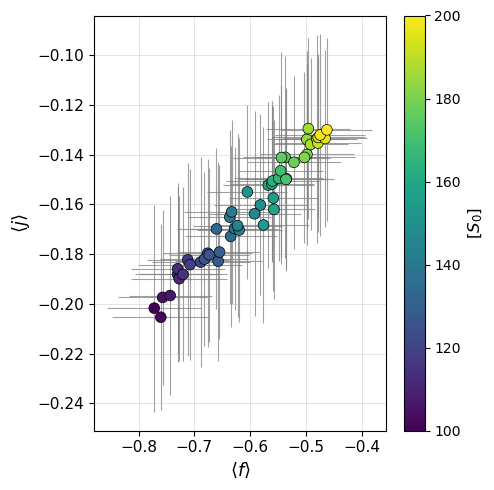

Saved: IF_curve_reaction_1.png


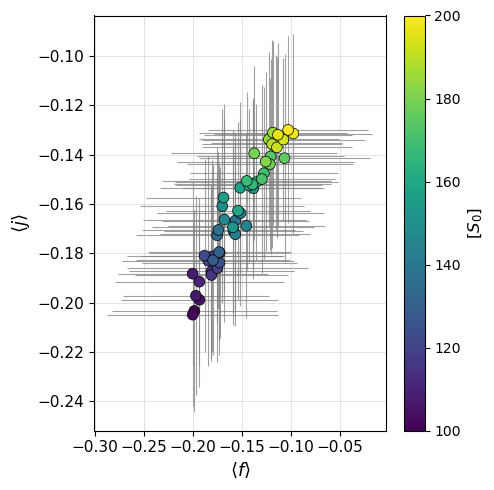

Saved: IF_curve_reaction_2.png


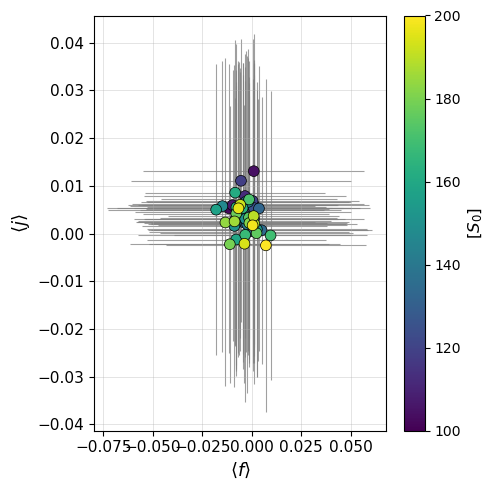

Saved: IF_curve_reaction_3.png


In [25]:
# We can plot the I-F curve for the sweep above:


SIM1.plot_IF_curves(reaction_indices=None,  # select which reaction you want to plot for, None does all the reactions
        analytical_currents=None,           # can overlay another set of current and force data if desired
        analytical_forces=None,
        show_errorbars=True,                # statistical error bars for both current and force
        colour_by_count=True)               # add a colour bar to indicate the value of the/one of the varied boundary conditions

In [26]:
# Now using the same data we can plot the numerical conductance matrices for each sweep:

SIM1.compute_conductances()

([Matrix([[0.208213832425111]]),
  Matrix([[0.213750524537822]]),
  Matrix([[0.208065336279422]]),
  Matrix([[0.209263820709042]]),
  Matrix([[0.202307654852326]]),
  Matrix([[0.20663980939201]]),
  Matrix([[0.204406502430805]]),
  Matrix([[0.208889578331182]]),
  Matrix([[0.204130476829488]]),
  Matrix([[0.209121727600889]]),
  Matrix([[0.209815822123493]]),
  Matrix([[0.208220297514585]]),
  Matrix([[0.213351643829724]]),
  Matrix([[0.212992610698109]]),
  Matrix([[0.218542137944452]]),
  Matrix([[0.216468225345886]]),
  Matrix([[0.207711840047596]]),
  Matrix([[0.213341135609171]]),
  Matrix([[0.211935506717192]]),
  Matrix([[0.208618356980302]]),
  Matrix([[0.208008837224038]]),
  Matrix([[0.219931895042856]]),
  Matrix([[0.21962053694745]]),
  Matrix([[0.216299338435073]]),
  Matrix([[0.213450104495251]]),
  Matrix([[0.208249173613207]]),
  Matrix([[0.229290173740611]]),
  Matrix([[0.216610122463337]]),
  Matrix([[0.21210560664636]]),
  Matrix([[0.22801158291973]]),
  Matrix([[0.2

No difference plotted: Option Deprecated


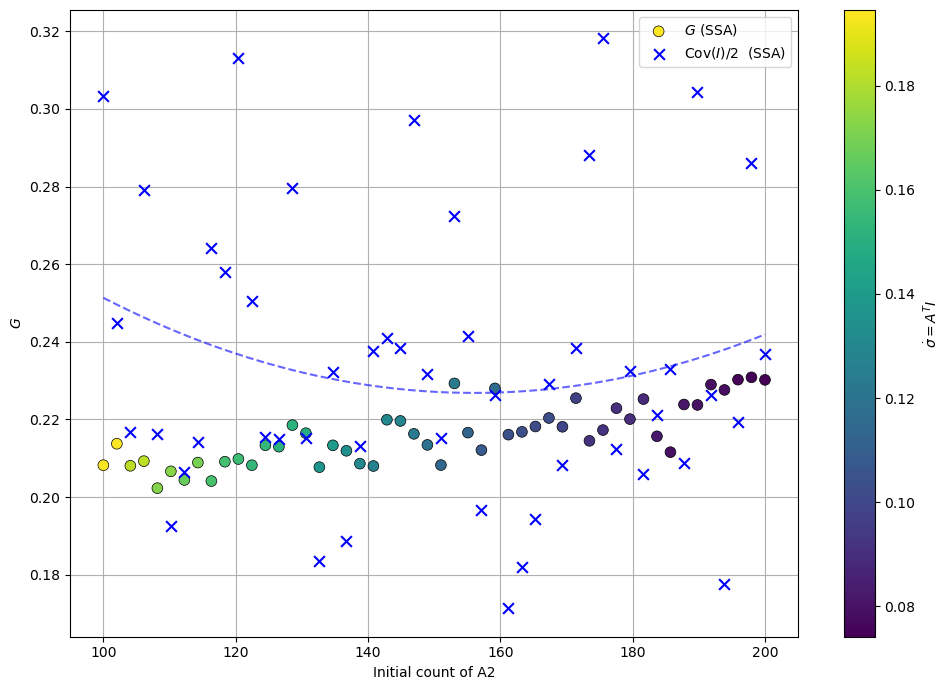

In [28]:
# And we can plot the fundamental conductance vs a chosen boundary condition species:

SIM1.plot_conductance(overlay_G=None,    # can overlay additional set of conductance values if desired
                    fit_order=2,            # select fit order for current covariance
                    show_covariance=True)   # can opt to plot the covariance
                     

### Demonstration 2: A Module with a fundamental conductance matrix

In [29]:
# Same process as before, the code automatically detects conductance is in matrix form and plots the eigenvalues instead.

SIM2.run_IF_sweep(species_index=[5], 
                count_values=[np.linspace(100,200,50)],
                total_iterations=100,
                covariance_reaction_indices=[2,4],
                verbose=True)

# Compute the conductance matrices:

SIM2.compute_conductances()

# Plot the eigenvalues of the conductance matrices, colour bar indicated average EPR for each set of boundary conditions:

SIM2.plot_conductance(analytical_G=None,    # can overlay additional set of conductance values if desired
                    fit_order=2,            # select fit order for current covariance
                    show_covariance=True)

Sweep 1/50  ([Nb] = 100)
Sweep 2/50  ([Nb] = 102)
Sweep 3/50  ([Nb] = 104)
Sweep 4/50  ([Nb] = 106)
Sweep 5/50  ([Nb] = 108)
Sweep 6/50  ([Nb] = 110)
Sweep 7/50  ([Nb] = 112)
Sweep 8/50  ([Nb] = 114)
Sweep 9/50  ([Nb] = 116)
Sweep 10/50  ([Nb] = 118)
Sweep 11/50  ([Nb] = 120)
Sweep 12/50  ([Nb] = 122)
Sweep 13/50  ([Nb] = 124)
Sweep 14/50  ([Nb] = 127)
Sweep 15/50  ([Nb] = 129)
Sweep 16/50  ([Nb] = 131)
Sweep 17/50  ([Nb] = 133)
Sweep 18/50  ([Nb] = 135)
Sweep 19/50  ([Nb] = 137)
Sweep 20/50  ([Nb] = 139)
Sweep 21/50  ([Nb] = 141)
Sweep 22/50  ([Nb] = 143)
Sweep 23/50  ([Nb] = 145)
Sweep 24/50  ([Nb] = 147)
Sweep 25/50  ([Nb] = 149)
Sweep 26/50  ([Nb] = 151)
Sweep 27/50  ([Nb] = 153)
Sweep 28/50  ([Nb] = 155)
Sweep 29/50  ([Nb] = 157)
Sweep 30/50  ([Nb] = 159)
Sweep 31/50  ([Nb] = 161)
Sweep 32/50  ([Nb] = 163)
Sweep 33/50  ([Nb] = 165)
Sweep 34/50  ([Nb] = 167)
Sweep 35/50  ([Nb] = 169)
Sweep 36/50  ([Nb] = 171)
Sweep 37/50  ([Nb] = 173)
Sweep 38/50  ([Nb] = 176)
Sweep 39/50  ([Nb] = 

TypeError: RunSSA.plot_conductance() got an unexpected keyword argument 'analytical_G'

### Demonstration 3: Combining Numerical Conductance Matrices

To do this, we need to consider two main things. Firstly, that the two sets of matrices we want to combine come from Modules which have overlapping species, and secondly that the species count values at which we are simulating the modules reflects the steady state of the combined module. This can be done by either: 1) Finding the joint network, simulating it, and extracting the steady state values of the overlapping species, or 2) running a flux minimisation algorithm across the connecting pin. Method two is much faster.

In [33]:
# An example script on how to use the Flux Minimisation code to find the overlap steady state values of the desired overlap species:

Na_index_mod1 = SIM1.species_names.index("Na")
Na_index_mod2 = SIM2.species_names.index("Na")

Na_stars = []

for S, Nb in zip(np.linspace(100, 200, 20, dtype=int), np.linspace(50, 150, 20, dtype=int)):

    mod1SIM = RunSSA(Module1, [150, 50, 30, S, 110], rates, simulation_length, burn_in)
    mod2SIM = RunSSA(Module2, [50, 50, 50, 80, 110, Nb, 200, 80], rates2, simulation_length, burn_in)

    Na_star = calculate_steady_state_overlap_counts(
        mod1SIM,
        mod2SIM,
        Na_index_mod1,
        Na_index_mod2,
        low_b=2,
        upper_b=300,
        iterations=1,
        tol=5
    )

    Na_stars.append(int(Na_star))
    print(f"S={S}, Nb={Nb} → Na* = {Na_star:.6f}")

  Na=2.00  J1=0.3171  J2=0.4683  J1+J2=0.7854
  Na=300.00  J1=-0.1227  J2=-0.4428  J1+J2=-0.5655
  Na=2.00  J1=0.2657  J2=0.4513  J1+J2=0.7171
  Na=300.00  J1=-0.1255  J2=-0.2856  J1+J2=-0.4112
  Na=191.39  J1=-0.0998  J2=-0.2599  J1+J2=-0.3597
  Na=96.70  J1=-0.0457  J2=-0.0057  J1+J2=-0.0514
  Na=84.06  J1=-0.0171  J2=-0.0400  J1+J2=-0.0571
  Na=43.03  J1=0.0628  J2=0.1600  J1+J2=0.2228
  Na=75.69  J1=-0.0086  J2=0.0600  J1+J2=0.0514
  Na=79.66  J1=0.0228  J2=0.0086  J1+J2=0.0314
S=100, Nb=50 → Na* = 79.657617
  Na=2.00  J1=0.2685  J2=0.4856  J1+J2=0.7541
  Na=300.00  J1=-0.1171  J2=-0.3428  J1+J2=-0.4599
  Na=2.00  J1=0.3114  J2=0.5791  J1+J2=0.8904
  Na=300.00  J1=-0.0828  J2=-0.3542  J1+J2=-0.4370
  Na=201.90  J1=-0.0628  J2=-0.2656  J1+J2=-0.3284
  Na=101.95  J1=-0.0257  J2=-0.1285  J1+J2=-0.1542
  Na=51.97  J1=0.0514  J2=0.1228  J1+J2=0.1743
  Na=78.49  J1=-0.0085  J2=0.0628  J1+J2=0.0543
  Na=84.60  J1=-0.0286  J2=-0.0257  J1+J2=-0.0543
  Na=81.54  J1=0.0086  J2=0.1398  J1+J2=0

In [34]:
# Now to simulate the modules at these steady state values of overlap species

SIM1.run_IF_sweep(

        species_index=[3,4],
        count_values=[np.linspace(100, 200, 20, dtype=int), Na_stars],
        total_iterations=500, 
        covariance_reaction_indices=None,   
        verbose=True)

SIM2.run_IF_sweep(

        species_index=[4,5],
        count_values=[Na_stars, np.linspace(50, 150, 20, dtype=int)],
        total_iterations=500, 
        covariance_reaction_indices=None,   
        verbose=True)

# Compute the conductance matrices:

M1_G,_ = SIM1.compute_conductances()
M2_G,_ = SIM2.compute_conductances()

Sweep 1/20  ([S] = 100, [Na] = 79)
Sweep 2/20  ([S] = 105, [Na] = 84)
Sweep 3/20  ([S] = 110, [Na] = 95)
Sweep 4/20  ([S] = 115, [Na] = 98)
Sweep 5/20  ([S] = 121, [Na] = 127)
Sweep 6/20  ([S] = 126, [Na] = 122)
Sweep 7/20  ([S] = 131, [Na] = 116)
Sweep 8/20  ([S] = 136, [Na] = 139)
Sweep 9/20  ([S] = 142, [Na] = 149)
Sweep 10/20  ([S] = 147, [Na] = 136)
Sweep 11/20  ([S] = 152, [Na] = 156)
Sweep 12/20  ([S] = 157, [Na] = 154)
Sweep 13/20  ([S] = 163, [Na] = 135)
Sweep 14/20  ([S] = 168, [Na] = 200)
Sweep 15/20  ([S] = 173, [Na] = 187)
Sweep 16/20  ([S] = 178, [Na] = 176)
Sweep 17/20  ([S] = 184, [Na] = 217)
Sweep 18/20  ([S] = 189, [Na] = 227)
Sweep 19/20  ([S] = 194, [Na] = 261)
Sweep 20/20  ([S] = 200, [Na] = 216)
Total sweep time: 6.91 s
Sweep 1/20  ([Na] = 79, [Nb] = 50)
Sweep 2/20  ([Na] = 84, [Nb] = 55)
Sweep 3/20  ([Na] = 95, [Nb] = 60)
Sweep 4/20  ([Na] = 98, [Nb] = 65)
Sweep 5/20  ([Na] = 127, [Nb] = 71)
Sweep 6/20  ([Na] = 122, [Nb] = 76)
Sweep 7/20  ([Na] = 116, [Nb] = 81)


In [35]:
# Prepare the object used to combine the matrices

Combined_Module = CombiningModules(Module1, Module2, M1_G, M2_G)

# And we recieve a set of numerical conductance matrices for the combined system:

numerical_G = Combined_Module.numerical_combined_fundamental_CMs

display(numerical_G)

Direct derivation force ordering:
  row/col 0: F-W        → resistance r4+r5+r6
  row/col 1: ???        → resistance r10+r9
  row/col 2: S-Pb       → resistance r1+r11+r12+r2+r5+r7+r8
  row/col 3: Ne-Pe      → resistance r13+r14

r9  = resistance of reaction 9  in M3 (shifted from r1 in M3 unshifted)
r10 = resistance of reaction 10 in M3 (shifted from r2 in M3 unshifted)
r11 = resistance of reaction 11 in M3
r12 = resistance of reaction 12 in M3
r13 = resistance of reaction 13 in M3
r14 = resistance of reaction 14 in M3

M3 has reactions c1..c6, shifted by n_rxn_l=3
So M3 reaction c1 → r4, c2 → r5, etc.
r9=c1, r10=c2, r11=c3, r12=c4, r13=c5, r14=c6

c1,c2 form cycle ε_c  (Nex→Pex): resistance r9+r10
c3,c4 form cycle ε_c' (Nb→Pb):   resistance r11+r12
c5,c6 form cycle ε_c''(Ne→Pe):   resistance r13+r14

STEP 1: IDENTIFY INTERFACE SPECIES
left_ext_names_list:  ['S', 'Na']
right_ext_names_list: ['Na', 'Nb', 'F', 'W']
interface_names:      ['Na']
left_free_rows:       [0]
right_free_rows: 

⎡⎡0.0836618882742035  0.0523187362301999⎤  ⎡0.0743226904467269  0.044502288047 ↪
⎢⎢                                      ⎥, ⎢                                   ↪
⎣⎣0.0523187362301999  0.178236849612747 ⎦  ⎣0.0445022880473821  0.166699924592 ↪

↪ 3821⎤  ⎡0.113906624953492   0.0693501506138922⎤  ⎡0.0757995059275412  0.0459 ↪
↪     ⎥, ⎢                                      ⎥, ⎢                           ↪
↪ 265 ⎦  ⎣0.0693501506138922   0.18350601741296 ⎦  ⎣ 0.04590854090397   0.1646 ↪

↪ 0854090397 ⎤  ⎡0.0837645088074344  0.0520232404826104⎤  ⎡0.0758531494256372  ↪
↪            ⎥, ⎢                                      ⎥, ⎢                    ↪
↪ 54019355683⎦  ⎣0.0520232404826104  0.150812134397342 ⎦  ⎣0.0464122423087362  ↪

↪  0.0464122423087362⎤  ⎡0.0784130058309173  0.0479764193501985⎤  ⎡0.074940727 ↪
↪                    ⎥, ⎢                                      ⎥, ⎢            ↪
↪  0.141593457743074 ⎦  ⎣0.0479764193501985  0.158376982750926 ⎦  ⎣0.046312419 ↪

↪ 1299021  0.04631241998

##### Verifying results compared to direct simulation of full network

In [36]:
# Can use CombiningModules to create new count lists and reaction rates lists in the correct order:

Ver_Combined_Module = CombiningModules(Module1,Module2) # Create CombiningModules object

# Create the combined counts and rates
# Note: This will ask user to input values of the overlapping species, in case it differs between modules.

comb_counts, comb_rates = Ver_Combined_Module.build_combined_initial_counts_and_rates(left_initial_counts=initial_counts, \
                                                                            right_initial_counts=initial_counts2,
                                                                            left_rates=rates, right_rates=rates2)

# Create new ModuleProperties object:

Comb_ModProp = ModuleProperties(Ver_Combined_Module.stoich_matrix, Ver_Combined_Module.num_internal_species, \
     Ver_Combined_Module.species_names)

# Create new RunSSA object:

Comb_Mod_SIM = RunSSA(Comb_ModProp, comb_counts, comb_rates, simulation_length =500, burn_in = 150 )

Direct derivation force ordering:
  row/col 0: F-W        → resistance r4+r5+r6
  row/col 1: ???        → resistance r10+r9
  row/col 2: S-Pb       → resistance r1+r11+r12+r2+r5+r7+r8
  row/col 3: Ne-Pe      → resistance r13+r14

r9  = resistance of reaction 9  in M3 (shifted from r1 in M3 unshifted)
r10 = resistance of reaction 10 in M3 (shifted from r2 in M3 unshifted)
r11 = resistance of reaction 11 in M3
r12 = resistance of reaction 12 in M3
r13 = resistance of reaction 13 in M3
r14 = resistance of reaction 14 in M3

M3 has reactions c1..c6, shifted by n_rxn_l=3
So M3 reaction c1 → r4, c2 → r5, etc.
r9=c1, r10=c2, r11=c3, r12=c4, r13=c5, r14=c6

c1,c2 form cycle ε_c  (Nex→Pex): resistance r9+r10
c3,c4 form cycle ε_c' (Nb→Pb):   resistance r11+r12
c5,c6 form cycle ε_c''(Ne→Pe):   resistance r13+r14

STEP 1: IDENTIFY INTERFACE SPECIES
left_ext_names_list:  ['S', 'Na']
right_ext_names_list: ['Na', 'Nb', 'F', 'W']
interface_names:      ['Na']
left_free_rows:       [0]
right_free_rows: 

In [37]:
# Then run the same process as before, ensuring the new indexing of S, Nb and Na is correct:

Comb_Mod_SIM.run_IF_sweep(

        species_index=[3,8,9],
        count_values=[Na_stars, np.linspace(100, 200, 20, dtype=int), np.linspace(50, 150, 20, dtype=int)],
        total_iterations=500, 
        covariance_reaction_indices=None,   
        verbose=True)


Sweep 1/20  ([Na] = 79, [S] = 100, [Nb] = 50)
Sweep 2/20  ([Na] = 84, [S] = 105, [Nb] = 55)
Sweep 3/20  ([Na] = 95, [S] = 110, [Nb] = 60)
Sweep 4/20  ([Na] = 98, [S] = 115, [Nb] = 65)
Sweep 5/20  ([Na] = 127, [S] = 121, [Nb] = 71)
Sweep 6/20  ([Na] = 122, [S] = 126, [Nb] = 76)
Sweep 7/20  ([Na] = 116, [S] = 131, [Nb] = 81)
Sweep 8/20  ([Na] = 139, [S] = 136, [Nb] = 86)
Sweep 9/20  ([Na] = 149, [S] = 142, [Nb] = 92)
Sweep 10/20  ([Na] = 136, [S] = 147, [Nb] = 97)
Sweep 11/20  ([Na] = 156, [S] = 152, [Nb] = 102)
Sweep 12/20  ([Na] = 154, [S] = 157, [Nb] = 107)
Sweep 13/20  ([Na] = 135, [S] = 163, [Nb] = 113)
Sweep 14/20  ([Na] = 200, [S] = 168, [Nb] = 118)
Sweep 15/20  ([Na] = 187, [S] = 173, [Nb] = 123)
Sweep 16/20  ([Na] = 176, [S] = 178, [Nb] = 128)
Sweep 17/20  ([Na] = 217, [S] = 184, [Nb] = 134)
Sweep 18/20  ([Na] = 227, [S] = 189, [Nb] = 139)
Sweep 19/20  ([Na] = 261, [S] = 194, [Nb] = 144)
Sweep 20/20  ([Na] = 216, [S] = 200, [Nb] = 150)
Total sweep time: 28.89 s


(array([[ 0.04285294,  0.04285294, -0.01142745, ..., -0.01714117,
         -0.1371294 , -0.13427253],
        [ 0.00571399,  0.00571399,  0.        , ..., -0.02285595,
         -0.09142381, -0.13999271],
        [-0.01142808, -0.0142851 ,  0.0142851 , ..., -0.07999658,
         -0.09428168, -0.12285189],
        ...,
        [ 0.01999692,  0.01999692, -0.01714022, ..., -0.05427736,
         -0.06570418, -0.07141758],
        [-0.02571385, -0.02571385, -0.01714257, ..., -0.07142736,
         -0.11999797, -0.13142635],
        [ 0.0257041 ,  0.02284809, -0.04855219, ..., -0.0257041 ,
         -0.13994454, -0.16279263]]),
 array([[ 0.21201403, -0.14204772,  0.03898821, ..., -0.03469695,
         -0.1248795 , -0.0070857 ],
        [ 0.24511937, -0.23319036, -0.12931113, ...,  0.01854468,
         -0.04767584,  0.00077128],
        [ 0.3017328 , -0.23430188, -0.00173024, ...,  0.04656649,
          0.01691539, -0.03278445],
        ...,
        [ 0.349839  , -0.3182468 ,  0.00225586, ..., -

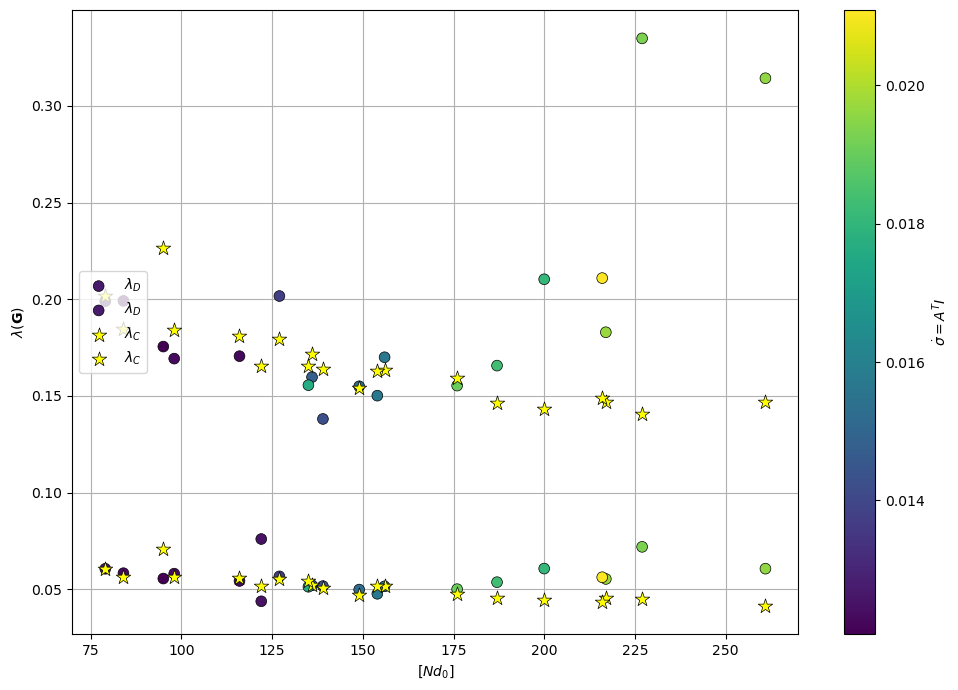

In [39]:
# Find the conductance matrices of the direct simulation:

comb_G, _ = Comb_Mod_SIM.compute_conductances()

# And can overlay the results of the combined numerical conductance eigenvalues onto the direct simulation, 
# pass the list of numerical conductance matrices as overlay_G:

Comb_Mod_SIM.plot_conductance(overlay_G=numerical_G,
        
        show_covariance=False,
        show_difference=False)